In [ ]:
import sys
sys.executable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from collections import defaultdict
import matplotlib.ticker as ticker
import glob
import os
import pickle
import sys
import re
import ast
sys.path.append("/scratch/halmazan//WCTE/WCTECoincidence_Analysis/Complete_analysis")

from matplotlib import rcParams
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [10, 8]
rcParams['font.size'] = 22

: 

In [2]:
#Runs to compare 
sig_run = '2386'
pos = [0.0, 0.0, -30.5]
bkg_run = '2384'

if sig_run == '2385':
    pos = [0.0, 0.0, +30.5]
    spills = 29764
elif sig_run == '2386':
    pos = [0.0, 0.0, -30.5]
    spills = 43840
elif sig_run == '2387':
    pos = [.0, 0.0, -58.5] #109682
elif sig_run == '2388':
    pos = [35.3553, -35.3553, +30.5] #89351
elif sig_run == '2389':
    pos = [35.3553, -35.3553, -30.5]


In [3]:
bkg_file = f'/data/halmazan/WCTE/data/AmBeCandidates/neutron_candidates_{bkg_run}_promptvar_neutronsel_test2.csv'
sig_file = f'/data/halmazan/WCTE/data/AmBeCandidates/neutron_candidates_{sig_run}_promptvar_neutronsel_test2.csv'
#input_sig_file = f'/data/halmazan/WCTE/data/filtered_files/filtered_file_{sig_run}.pkl'

df = pd.read_csv(sig_file)
df_bkg = pd.read_csv(bkg_file)

In [6]:
per_event = (
    df.assign(total_nhits=df["prompt_nhits"].fillna(0) + df["delayed_nhits"].fillna(0))
      .groupby("event_number")
      .agg(
          nhits=("total_nhits", "sum"),   # total hits per event
          candidates=("event_number", "size"),  # rows per event
      )
)

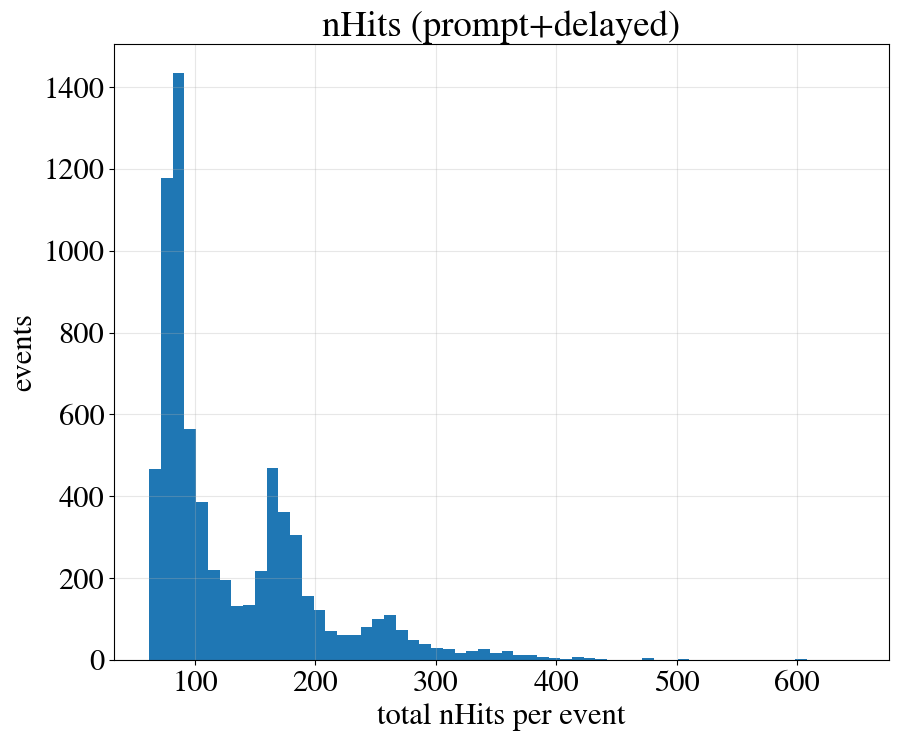

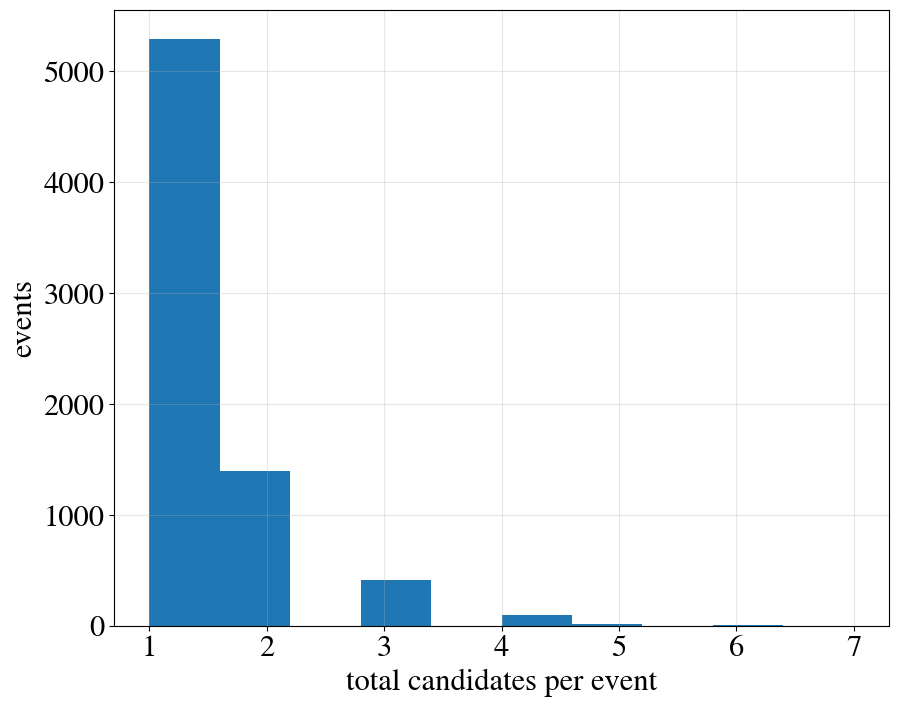

In [11]:
plt.figure()
plt.hist(per_event["nhits"], bins=60)
plt.xlabel('total nHits per event')
plt.ylabel('events')
plt.title(f'nHits (prompt+delayed)')
#plt.yscale('log') 
plt.grid(alpha=0.3)
#print(hist_sig)

plt.figure()
plt.hist(per_event["candidates"], bins=10)
plt.xlabel('total candidates per event')
plt.ylabel('events')
plt.title(f'')
#plt.yscale('log') 
plt.grid(alpha=0.3)
#print(hist_sig)